In [ ]:
import pandas as pd

df = pd.read_csv("../Data/Zomato Dataset.csv")

print(df.shape)
print(df.columns)

(45584, 20)
Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='str')


In [ ]:
print(df.isna().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.shape)

(45584, 20)


In [ ]:
print(df.dtypes)

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weather_conditions                 str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries            float64
Festival                           str
City                               str
Time_taken (min)                 int64
dtype: object


In [ ]:
print(df["Order_Date"].head())
print(df["Time_Orderd"].head())
print(df["Time_Order_picked"].head())

0    12-02-2022
1    13-02-2022
2    04-03-2022
3    13-02-2022
4    14-02-2022
Name: Order_Date, dtype: str
0    21:55
1    14:55
2    17:30
3    09:20
4    19:50
Name: Time_Orderd, dtype: str
0    22:10
1    15:05
2    17:40
3    09:30
4    20:05
Name: Time_Order_picked, dtype: str


In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format= "%d-%m-%Y")


In [ ]:
print(df["Order_Date"].head())
print(df["Order_Date"].dtype)

0   2022-02-12
1   2022-02-13
2   2022-03-04
3   2022-02-13
4   2022-02-14
Name: Order_Date, dtype: datetime64[us]
datetime64[us]


In [ ]:
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M"
)

df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format="%H:%M"
)

ValueError: time data "0.458333333" doesn't match format "%H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
print(df["Time_Orderd"].value_counts().head(20))

Time_Orderd
21:55          461
17:55          456
0.833333333    449
22:20          448
21:35          446
19:50          444
21:15          442
22:45          438
21:20          437
18:35          436
19:55          436
21:25          435
18:10          435
17:35          435
22:10          434
23:30          434
17:25          431
17:40          431
1              430
23:25          429
Name: count, dtype: int64


In [ ]:
print(df["Time_Orderd"].tail(20))

45564    20:40
45565    22:15
45566    21:45
45567    17:25
45568    22:10
45569    10:25
45570    18:10
45571    09:10
45572    20:25
45573    0.375
45574    21:10
45575    09:35
45576    18:10
45577    21:55
45578    21:45
45579    11:35
45580    19:55
45581    23:50
45582    13:35
45583    17:10
Name: Time_Orderd, dtype: str


In [ ]:
print(df["Time_Orderd"].str.contains(":").sum())

print(df["Time_Orderd"].str.contains(":").value_counts())

39785
Time_Orderd
True     39785
False     5799
Name: count, dtype: int64


In [ ]:
print(df.loc[~df["Time_Orderd"].str.contains(":"), "Time_Orderd"].value_counts().head(20))

Time_Orderd
0.833333333    449
1              430
0.791666667    424
0.958333333    422
0.875          409
0.916666667    404
0.75           402
0.416666667    211
0.458333333    193
0.5            189
0.375          177
0.625           86
0.541666667     79
0.583333333     74
0.708333333     66
0.666666667     53
Name: count, dtype: int64


In [ ]:
def convert_time(value):
    if pd.isna(value):
        return value
    if ":" in value:
        return value
    return pd.to_datetime(float(value), unit="D").strftime("%H:%M")

In [ ]:
df["Time_Orderd"] = df["Time_Orderd"].apply(convert_time)

In [ ]:
print(df["Time_Orderd"].head(20))

0     21:55
1     14:55
2     17:30
3     09:20
4     19:50
5     20:25
6     14:55
7     20:30
8     20:40
9     21:15
10    20:20
11    22:30
12    08:15
13    19:30
14    12:25
15    18:35
16    20:35
17    23:20
18    21:20
19    23:35
Name: Time_Orderd, dtype: str


In [ ]:
print(df["Time_Order_picked"].str.contains(":").value_counts())

Time_Order_picked
True     41457
False     4127
Name: count, dtype: int64


In [ ]:
print(df["Time_Order_picked"].isnull().sum())

0


In [ ]:
print(
    df.loc[
        ~df["Time_Order_picked"].str.contains(":"),
        "Time_Order_picked"
    ].value_counts().head(20)
)

Time_Order_picked
0.833333333    452
1              440
0.916666667    430
0.75           422
0.875          416
0.958333333    411
0.791666667    403
0.375          201
0.416666667    194
0.5            188
0.458333333    148
0.625          100
0.666666667     91
0.541666667     83
0.583333333     82
0.708333333     66
Name: count, dtype: int64


In [ ]:
def convert_time(value):
    if pd.isna(value):
        return value
    if ":" in value:
        return value
    return pd.to_datetime(float(value), unit="D").strftime("%H:%M")

In [ ]:
df["Time_Order_picked"] = df["Time_Order_picked"].apply(convert_time)

In [ ]:
print(df["Time_Order_picked"].head(20))

0     22:10
1     15:05
2     17:40
3     09:30
4     20:05
5     20:35
6     15:10
7     20:40
8     20:50
9     21:30
10    20:25
11    22:45
12    08:30
13    19:45
14    12:30
15    18:50
16    20:40
17    23:30
18    21:35
19    23:45
Name: Time_Order_picked, dtype: str


In [ ]:
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64


In [ ]:
#fill the missing ages with median

print(df["Delivery_person_Age"].median())



30.0


In [ ]:
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())

print(df["Delivery_person_Age"].isnull().sum())

0


In [ ]:
print(df["Delivery_person_Ratings"].median())

4.7


In [ ]:
print(df["multiple_deliveries"].value_counts(dropna=False))

multiple_deliveries
1.0    28151
0.0    14094
2.0     1985
NaN      993
3.0      361
Name: count, dtype: int64


In [ ]:
print(df["Festival"].value_counts(dropna=False))

Festival
No     44460
Yes      896
NaN      228
Name: count, dtype: int64


In [ ]:
print(df["Weather_conditions"].value_counts(dropna=False))

Weather_conditions
Fog           7653
Stormy        7584
Cloudy        7533
Sandstorms    7494
Windy         7422
Sunny         7282
NaN            616
Name: count, dtype: int64


In [ ]:
df["Weather_conditions"] = df["Weather_conditions"].fillna("Unknown")

In [ ]:
print(df["Weather_conditions"].isnull().sum())

0


In [ ]:
print(df["Road_traffic_density"].value_counts(dropna=False))

Road_traffic_density
Low       15476
Jam       14139
Medium    10945
High       4423
NaN         601
Name: count, dtype: int64


In [ ]:
df["Road_traffic_density"] = df["Road_traffic_density"].fillna("Unknown")

In [ ]:
print(df["Road_traffic_density"].isnull().sum())

0


In [ ]:
print(df["City"].value_counts(dropna=False))

City
Metropolitian    34087
Urban            10133
NaN               1200
Semi-Urban         164
Name: count, dtype: int64


In [ ]:
df["City"] = df["City"].fillna("Unknown")

In [ ]:
print(df["City"].isnull().sum())

0


In [ ]:
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                              0
Time_taken (min)                  0
dtype: int64


In [ ]:
print(df["Delivery_person_Age"].describe())

count    45584.000000
mean        29.584525
std          5.696221
min         15.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64


In [ ]:
print(df["Delivery_person_Ratings"].describe())

count    43676.000000
mean         4.633774
std          0.334744
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64


In [ ]:
print((df["Delivery_person_Ratings"] < 1).sum())
print((df["Delivery_person_Ratings"] > 5).sum())

0
53


In [ ]:
import numpy as np

df.loc[
    df["Delivery_person_Ratings"] > 5,
    "Delivery_person_Ratings"
] = np.nan

In [ ]:
print((df["Delivery_person_Ratings"] > 5).sum())

0


In [ ]:
print(df["Delivery_person_Ratings"].isnull().sum())

1961


In [ ]:
print(df["Time_taken (min)"].describe())

count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64


In [ ]:
print(df["Vehicle_condition"].value_counts(dropna=False).sort_index())

Vehicle_condition
0    15005
1    15028
2    15031
3      520
Name: count, dtype: int64


In [ ]:
print(df["Type_of_vehicle"].value_counts(dropna=False))

Type_of_vehicle
motorcycle          26429
scooter             15273
electric_scooter     3814
bicycle                68
Name: count, dtype: int64


In [ ]:
print(df["Type_of_order"].value_counts(dropna=False))

Type_of_order
Snack     11530
Meal      11456
Drinks    11321
Buffet    11277
Name: count, dtype: int64


In [ ]:
print(df["multiple_deliveries"].value_counts(dropna=False).sort_index())

multiple_deliveries
0.0    14094
1.0    28151
2.0     1985
3.0      361
NaN      993
Name: count, dtype: int64


In [ ]:
print(df["Festival"].value_counts(dropna=False))

Festival
No     44460
Yes      896
NaN      228
Name: count, dtype: int64


In [ ]:
print(df["ID"].nunique())
print(df["Delivery_person_ID"].nunique())

45584
1320


In [ ]:
print(df["ID"].duplicated().sum())

0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
import os
print(os.getcwd())

e:\python_projects\Food-Delivery-Analytics\Python


In [ ]:
import os

os.makedirs("../Data", exist_ok=True)

In [ ]:
df.to_csv("../Data/zomato_delivery_cleaned.csv", index=False)

In [ ]:
df = pd.read_csv("../Data/zomato_delivery_cleaned.csv")
print(df.shape)

(45584, 20)


In [ ]:
print(df["Time_taken (min)"].mean())

26.293962793962795


In [ ]:
print(df["Time_taken (min)"].median())

26.0


In [ ]:
df.groupby("Type_of_order")["Time_taken (min)"].mean()

Type_of_order
Buffet    26.283320
Drinks    26.187969
Meal      26.417598
Snack     26.285603
Name: Time_taken (min), dtype: float64

In [ ]:
df.groupby("Road_traffic_density")["Time_taken (min)"].mean()

Road_traffic_density
High       27.240109
Jam        31.176038
Low        21.266671
Medium     26.699680
Unknown    26.542429
Name: Time_taken (min), dtype: float64

In [ ]:
df.groupby("multiple_deliveries")["Time_taken (min)"].mean()

multiple_deliveries
0.0    22.876188
1.0    26.854925
2.0    40.454912
3.0    47.819945
Name: Time_taken (min), dtype: float64

In [ ]:
print(df["multiple_deliveries"].value_counts(dropna = False))

multiple_deliveries
1.0    28151
0.0    14094
2.0     1985
NaN      993
3.0      361
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='str')


In [ ]:
print(df["Time_taken (min)"])

0        46
1        23
2        21
3        20
4        41
         ..
45579    32
45580    36
45581    16
45582    26
45583    36
Name: Time_taken (min), Length: 45584, dtype: int64


In [ ]:
df.groupby("Weather_conditions")["Time_taken (min)"].mean()

Weather_conditions
Cloudy        28.917164
Fog           28.914674
Sandstorms    25.875500
Stormy        25.868803
Sunny         21.856770
Unknown       26.545455
Windy         26.118836
Name: Time_taken (min), dtype: float64

# Delivery times vary substantially across weather conditions, with the shortest average delivery time during Sunny conditions and the longest during Cloudy and Fog conditions

In [ ]:
df["Weather_conditions"].value_counts(dropna=False)

Weather_conditions
Fog           7653
Stormy        7584
Cloudy        7533
Sandstorms    7494
Windy         7422
Sunny         7282
Unknown        616
Name: count, dtype: int64

In [ ]:
df.groupby("City")["Time_taken (min)"].mean()

City
Metropolitian    27.314460
Semi-Urban       49.731707
Unknown          22.058333
Urban            22.983322
Name: Time_taken (min), dtype: float64

In [ ]:
df["City"].value_counts(dropna=False)

City
Metropolitian    34087
Urban            10133
Unknown           1200
Semi-Urban         164
Name: count, dtype: int64

In [ ]:
semi_urban = df[df["City"] == "Semi-Urban"]

semi_urban["Time_taken (min)"].agg(["min", "max", "median", "mean"])

min       44.000000
max       54.000000
median    49.000000
mean      49.731707
Name: Time_taken (min), dtype: float64

In [ ]:
df.groupby("Type_of_vehicle")["Time_taken (min)"].mean()


Type_of_vehicle
bicycle             26.426471
electric_scooter    24.470110
motorcycle          27.605774
scooter             24.478819
Name: Time_taken (min), dtype: float64

In [ ]:
vehicle_type = df[df["Type_of_vehicle"]=="bicycle"]
len(vehicle_type)

68

# Motorcycles have the highest average delivery time among the major vehicle categories, while scooters and electric scooters have lower average delivery times.

In [ ]:
df.groupby("Festival")["Time_taken (min)"].mean()

Festival
No     25.984121
Yes    45.517857
Name: Time_taken (min), dtype: float64

In [ ]:
festival_day = df[df["Festival"] == "Yes"]
len(festival_day)


896

In [ ]:
df.groupby(["Festival", "Road_traffic_density"]).size()

Festival  Road_traffic_density
No        High                     4336
          Jam                     13469
          Low                     15298
          Medium                  10776
          Unknown                   581
Yes       High                       69
          Jam                       630
          Low                        50
          Medium                    130
          Unknown                    17
dtype: int64

In [ ]:
pd.crosstab(
    df["Festival"],
    df["Road_traffic_density"],
    normalize="index"
) * 100

Road_traffic_density,High,Jam,Low,Medium,Unknown
Festival,,,,,
No,9.752587,30.294647,34.408457,24.237517,1.306793
Yes,7.700893,70.312500,5.580357,14.508929,1.897321


In [ ]:
df["Delivery_person_Ratings"].corr(df["Time_taken (min)"])

np.float64(-0.3412237373758315)

In [ ]:
df.groupby("Vehicle_condition")["Time_taken (min)"].mean()

Vehicle_condition
0    30.073109
1    24.353673
2    24.454394
3    26.492308
Name: Time_taken (min), dtype: float64

In [ ]:
df["Vehicle_condition"].value_counts()

Vehicle_condition
2    15031
1    15028
0    15005
3      520
Name: count, dtype: int64

In [ ]:
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M",
    errors="coerce"
)

In [ ]:
df["Order_Hour"] = df["Time_Orderd"].dt.hour

In [ ]:
df[["Time_Orderd", "Order_Hour"]].head(20)

,Time_Orderd,Order_Hour
0,1900-01-01 21:55:00,21.0
1,1900-01-01 14:55:00,14.0
2,1900-01-01 17:30:00,17.0
3,1900-01-01 09:20:00,9.0
4,1900-01-01 19:50:00,19.0
5,1900-01-01 20:25:00,20.0
6,1900-01-01 14:55:00,14.0
7,1900-01-01 20:30:00,20.0
8,1900-01-01 20:40:00,20.0
9,1900-01-01 21:15:00,21.0


In [ ]:
df.groupby("Order_Hour")["Time_taken (min)"].mean()

Order_Hour
0.0     22.169767
8.0     19.580627
9.0     19.543914
10.0    19.457875
11.0    27.165158
12.0    26.826233
13.0    27.529755
14.0    27.543933
15.0    23.194731
16.0    22.932903
17.0    27.477559
18.0    27.276178
19.0    30.862158
20.0    31.178528
21.0    31.090928
22.0    23.145458
23.0    22.435314
Name: Time_taken (min), dtype: float64

In [ ]:
Order_Hours = df[df["Order_Hour"] == 0]
len(Order_Hours)

430

In [ ]:
df.loc[df["Order_Hour"] == 0, "Time_Orderd"].value_counts(dropna=False)

Time_Orderd
1900-01-01    430
Name: count, dtype: int64

In [ ]:
df["Order_Hour"].value_counts(dropna=False)

Order_Hour
19.0    5042
22.0    4998
21.0    4685
18.0    4479
17.0    4211
20.0    4089
23.0    4089
10.0    2184
9.0     1947
8.0     1817
11.0    1768
NaN     1731
12.0     892
15.0     873
13.0     857
16.0     775
14.0     717
0.0      430
Name: count, dtype: int64

In [ ]:
df.loc[df["Order_Hour"] == 0, "Order_Hour"] = np.nan

In [ ]:
df.groupby("Order_Hour")["Time_taken (min)"].mean()

Order_Hour
8.0     19.580627
9.0     19.543914
10.0    19.457875
11.0    27.165158
12.0    26.826233
13.0    27.529755
14.0    27.543933
15.0    23.194731
16.0    22.932903
17.0    27.477559
18.0    27.276178
19.0    30.862158
20.0    31.178528
21.0    31.090928
22.0    23.145458
23.0    22.435314
Name: Time_taken (min), dtype: float64

In [ ]:
df.groupby(["Order_Hour", "Road_traffic_density"])["Time_taken (min)"].mean()

Order_Hour  Road_traffic_density
8.0         Low                     19.580627
9.0         Low                     19.543914
10.0        Low                     19.457875
11.0        High                    27.165158
12.0        High                    26.826233
13.0        High                    27.529755
14.0        High                    27.543933
15.0        High                    26.069767
            Medium                  22.880559
16.0        Medium                  22.932903
17.0        Medium                  27.477559
18.0        Medium                  27.276178
19.0        Jam                     31.187527
            Medium                  27.318396
20.0        Jam                     31.178528
21.0        Jam                     31.090928
22.0        Jam                     31.245050
            Low                     22.433174
23.0        Low                     22.435314
Name: Time_taken (min), dtype: float64

In [ ]:
df.groupby(["Order_Hour", "Road_traffic_density"]).size()

Order_Hour  Road_traffic_density
8.0         Low                     1817
9.0         Low                     1947
10.0        Low                     2184
11.0        High                    1768
12.0        High                     892
13.0        High                     857
14.0        High                     717
15.0        High                      86
            Medium                   787
16.0        Medium                   775
17.0        Medium                  4211
18.0        Medium                  4479
19.0        Jam                     4618
            Medium                   424
20.0        Jam                     4089
21.0        Jam                     4685
22.0        Jam                      404
            Low                     4594
23.0        Low                     4089
dtype: int64

# "Delivery time is strongly associated with traffic conditions and order hour. Morning orders during low traffic average around 19.5 minutes, while evening orders during jam traffic average around 31 minutes."

In [ ]:
df.groupby(["Order_Hour", "multiple_deliveries"]).size()

Order_Hour  multiple_deliveries
8.0         0.0                     737
            1.0                    1034
            2.0                       1
9.0         0.0                     765
            1.0                    1111
            2.0                       2
10.0        0.0                     884
            1.0                    1247
11.0        0.0                     496
            1.0                    1160
            2.0                      63
            3.0                      11
12.0        0.0                     255
            1.0                     585
            2.0                      35
            3.0                       6
13.0        0.0                     220
            1.0                     572
            2.0                      39
            3.0                      10
14.0        0.0                     209
            1.0                     450
            2.0                      33
            3.0                       7
15.0    

In [ ]:
pd.crosstab(df["Order_Hour"], df["multiple_deliveries"],normalize="index") * 100

multiple_deliveries,0.0,1.0,2.0,3.0
Order_Hour,,,,
8.0,41.591422,58.352144,0.056433,0.000000
9.0,40.734824,59.158679,0.106496,0.000000
10.0,41.482872,58.517128,0.000000,0.000000
11.0,28.670520,67.052023,3.641618,0.635838
12.0,28.944381,66.401816,3.972758,0.681044
13.0,26.159334,68.014269,4.637337,1.189061
14.0,29.899857,64.377682,4.721030,1.001431
15.0,35.446009,63.849765,0.704225,0.000000
16.0,36.184211,63.157895,0.657895,0.000000


In [ ]:
df.groupby(["Road_traffic_density", "multiple_deliveries"])["Time_taken (min)"].mean()

Road_traffic_density  multiple_deliveries
High                  0.0                    23.980630
                      1.0                    27.729289
                      2.0                    39.760000
                      3.0                    47.828571
Jam                   0.0                    27.538844
                      1.0                    30.943464
                      2.0                    41.464935
                      3.0                    48.185606
Low                   0.0                    19.241947
                      1.0                    22.297256
                      2.0                    38.653179
                      3.0                    43.600000
Medium                0.0                    23.692613
                      1.0                    27.268683
                      2.0                    38.863436
                      3.0                    46.180000
Unknown               0.0                    23.281915
                      1

In [ ]:
df.groupby(["Road_traffic_density", "multiple_deliveries"]).size()

Road_traffic_density  multiple_deliveries
High                  0.0                    1239
                      1.0                    2885
                      2.0                     175
                      3.0                      35
Jam                   0.0                    3617
                      1.0                    8844
                      2.0                    1155
                      3.0                     264
Low                   0.0                    5774
                      1.0                    9110
                      2.0                     173
                      3.0                       5
Medium                0.0                    3276
                      1.0                    6945
                      2.0                     454
                      3.0                      50
Unknown               0.0                     188
                      1.0                     367
                      2.0                      28
        

# Both road traffic density and multiple deliveries are associated with longer delivery times. However, multiple deliveries show a particularly strong and consistent relationship with delivery time across all traffic conditions. The combination of heavy traffic and multiple deliveries corresponds to the longest average delivery times.

In [ ]:
df.groupby("Delivery_person_Age")["Time_taken (min)"].mean()

Delivery_person_Age
15.0    26.000000
20.0    22.898876
21.0    22.908500
22.0    22.927985
23.0    23.196069
24.0    23.059729
25.0    22.819227
26.0    22.948124
27.0    23.053023
28.0    23.166590
29.0    22.916933
30.0    27.941176
31.0    29.659906
32.0    29.885961
33.0    29.489936
34.0    29.605543
35.0    29.607253
36.0    29.500885
37.0    29.250674
38.0    29.451758
39.0    29.739739
50.0    23.943396
Name: Time_taken (min), dtype: float64

In [ ]:
df["Delivery_person_Age"].corr(df["Time_taken (min)"])

np.float64(0.2929091643930686)

# Delivery-person age has a weak-to-moderate positive association with delivery time (r ≈ 0.29), suggesting that delivery times tend to increase somewhat with age, but age alone does not strongly explain delivery-time variation.

In [ ]:
df["Delivery_person_Ratings"].corr(df["Time_taken (min)"])

np.float64(-0.3412237373758315)

# "Delivery-person rating has a weak-to-moderate negative association with delivery time, indicating that higher-rated delivery personnel tend to have somewhat shorter delivery times."

In [ ]:
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [ ]:
df["Distance_km"] = calculate_distance(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

In [ ]:
df["Distance_km"].describe()

count    45584.000000
mean        99.321320
std       1099.839139
min          1.465067
25%          4.663493
50%          9.264356
75%         13.763977
max      19692.674606
Name: Distance_km, dtype: float64

In [ ]:
df.nlargest(10, "Distance_km")[[
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Distance_km"
]]

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km
33524,-22.533662,-88.366217,22.663662,88.496217,19692.674606
6779,-22.552672,-88.352885,22.662672,88.462885,19688.001288
2475,-22.538999,-88.322337,22.668999,88.452337,19683.687561
18817,-22.537960,-88.349843,22.547960,88.359843,19677.180552
9526,-23.374989,-85.335486,23.444989,85.405486,19070.408110
753,-23.359194,-85.325447,23.449194,85.415447,19070.337839
35526,-23.369746,-85.339820,23.419746,85.389820,19069.158946
22282,-23.351058,-85.325731,23.421058,85.395731,19068.246962
30624,-23.357804,-85.325146,23.417804,85.385146,19067.128547
43445,-23.351058,-85.325731,23.401058,85.375731,19066.150742


In [ ]:
(df["Restaurant_latitude"] < 0).sum()

np.int64(431)

In [ ]:
(df["Restaurant_longitude"] < 0).sum()

np.int64(162)

In [ ]:
((df["Restaurant_latitude"] < 0) & 
 (df["Restaurant_longitude"] < 0)).sum()

np.int64(162)

In [ ]:
((df["Restaurant_latitude"] < 0) & 
 (df["Restaurant_longitude"] < 0) &
 (df["Delivery_location_latitude"] > 0) &
 (df["Delivery_location_longitude"] > 0)).sum()

np.int64(162)

In [ ]:
df["Restaurant_latitude"].abs()

0        30.327968
1        10.003064
2        18.562450
3        30.899584
4        26.463504
           ...    
45579    26.902328
45580     0.000000
45581    13.022394
45582    11.001753
45583    23.351058
Name: Restaurant_latitude, Length: 45584, dtype: float64

In [ ]:
df["Restaurant_latitude_corrected"] = df["Restaurant_latitude"]
df["Restaurant_longitude_corrected"] = df["Restaurant_longitude"]

mask = (
    (df["Restaurant_latitude"] < 0) &
    (df["Restaurant_longitude"] < 0) &
    (df["Delivery_location_latitude"] > 0) &
    (df["Delivery_location_longitude"] > 0)
)

df.loc[mask, "Restaurant_latitude_corrected"] = df.loc[mask, "Restaurant_latitude"].abs()
df.loc[mask, "Restaurant_longitude_corrected"] = df.loc[mask, "Restaurant_longitude"].abs()

In [ ]:
df["Restaurant_latitude"] = df["Restaurant_latitude"].abs()

In [ ]:
df.loc[33524, [
    "Restaurant_latitude",
    "Restaurant_latitude_corrected",
    "Restaurant_longitude",
    "Restaurant_longitude_corrected"
]]

Restaurant_latitude               22.533662
Restaurant_latitude_corrected     22.533662
Restaurant_longitude             -88.366217
Restaurant_longitude_corrected    88.366217
Name: 33524, dtype: float64

In [ ]:
df["Distance_km_corrected"] = calculate_distance(
    df["Restaurant_latitude_corrected"],
    df["Restaurant_longitude_corrected"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

In [ ]:
df["Distance_km_corrected"].describe()

count    45584.000000
mean        37.494659
std        373.242362
min          1.465067
25%          4.663439
50%          9.220582
75%         13.735922
max       6884.726399
Name: Distance_km_corrected, dtype: float64

In [ ]:
df.nlargest(10, "Distance_km_corrected")[[
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Distance_km_corrected"
]]

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km_corrected
4066,30.902872,75.826808,31.012872,75.936808,6884.726399
2899,30.895817,75.813112,31.005817,75.923112,6883.157441
2627,30.902872,75.826808,30.972872,75.896808,6880.272782
25862,30.895817,75.813112,30.965817,75.883112,6878.703822
23148,30.899584,75.809346,30.959584,75.869346,6878.428563
18877,30.885814,75.786976,30.965814,75.866976,6877.592421
26656,30.899584,75.809346,30.949584,75.859346,6877.315724
24779,30.873988,75.842739,30.963988,75.932739,6876.075767
9860,30.885915,75.788259,30.945915,75.848259,6875.388718
8240,30.899584,75.809346,30.929584,75.839346,6875.090529


In [ ]:
calculate_distance(
    30.902872,
    75.826808,
    31.012872,
    75.936808
)

np.float64(16.112965527489266)

In [ ]:
df.loc[4066, [
    "Restaurant_latitude_corrected",
    "Restaurant_longitude_corrected",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Distance_km_corrected"
]]

Restaurant_latitude_corrected      -30.902872
Restaurant_longitude_corrected      75.826808
Delivery_location_latitude          31.012872
Delivery_location_longitude         75.936808
Distance_km_corrected             6884.726399
Name: 4066, dtype: float64

In [ ]:
df["Restaurant_latitude_corrected"] = df["Restaurant_latitude"].abs()
df["Restaurant_longitude_corrected"] = df["Restaurant_longitude"].abs()

In [ ]:
df["Distance_km_corrected"] = calculate_distance(
    df["Restaurant_latitude_corrected"],
    df["Restaurant_longitude_corrected"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

In [ ]:
df.loc[4066, [
    "Restaurant_latitude_corrected",
    "Restaurant_longitude_corrected",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Distance_km_corrected"
]]

Restaurant_latitude_corrected     30.902872
Restaurant_longitude_corrected    75.826808
Delivery_location_latitude        31.012872
Delivery_location_longitude       75.936808
Distance_km_corrected             16.112966
Name: 4066, dtype: float64

In [ ]:
df["Distance_km_corrected"].describe()

count    45584.000000
mean         9.735119
std          5.608034
min          1.465067
25%          4.663345
50%          9.220148
75%         13.681492
max         20.969489
Name: Distance_km_corrected, dtype: float64

In [ ]:
df["Distance_km_corrected"].corr(df["Time_taken (min)"])

np.float64(0.3210985305080679)

# Delivery distance has a positive but relatively weak-to-moderate relationship with delivery time. Other factors such as traffic and multiple deliveries appear to have stronger effects.

In [ ]:
key_findings = {
    "Distance vs Time correlation": 0.3211,
    "Rating vs Time correlation": -0.3412
}

key_findings

{'Distance vs Time correlation': 0.3211, 'Rating vs Time correlation': -0.3412}

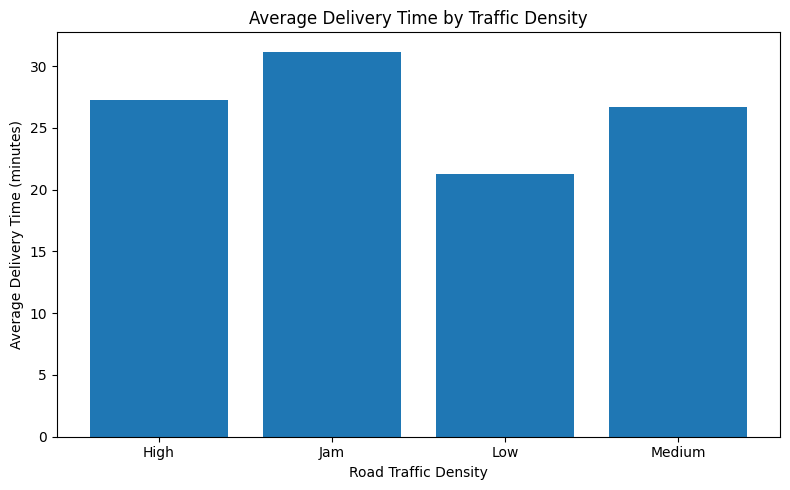

In [ ]:

traffic_time = df.groupby("Road_traffic_density")["Time_taken (min)"].mean()

traffic_time_clean = traffic_time.drop("Unknown")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(traffic_time_clean.index, traffic_time_clean.values)

plt.xlabel("Road Traffic Density")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Traffic Density")

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_traffic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

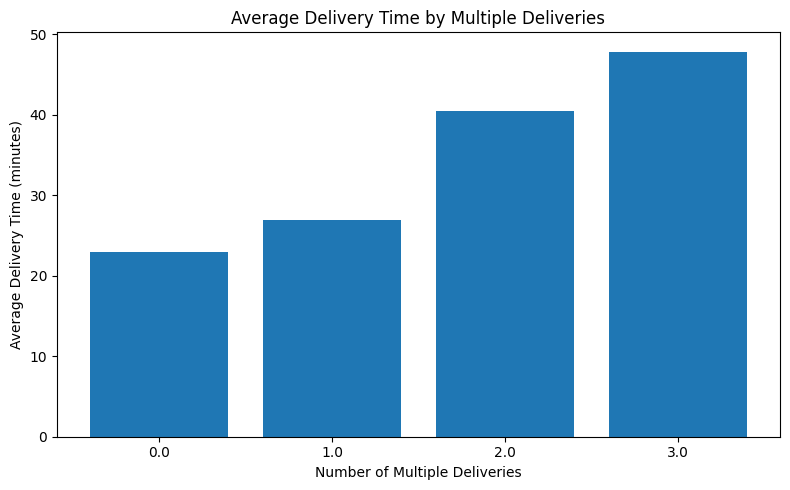

In [ ]:

delivery_time = df.groupby("multiple_deliveries")["Time_taken (min)"].mean()

delivery_time

plt.figure(figsize=(8, 5))

plt.bar(delivery_time.index.astype(str), delivery_time.values)

plt.xlabel("Number of Multiple Deliveries")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Multiple Deliveries")

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_multiple_deliveries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='str')

In [ ]:
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M",
    errors="coerce"
)

In [ ]:
df["Order_Hour"] = df["Time_Orderd"].dt.hour

In [ ]:
df["Time_Orderd"].head(10)

0   1900-01-01 21:55:00
1   1900-01-01 14:55:00
2   1900-01-01 17:30:00
3   1900-01-01 09:20:00
4   1900-01-01 19:50:00
5   1900-01-01 20:25:00
6   1900-01-01 14:55:00
7   1900-01-01 20:30:00
8   1900-01-01 20:40:00
9   1900-01-01 21:15:00
Name: Time_Orderd, dtype: datetime64[us]

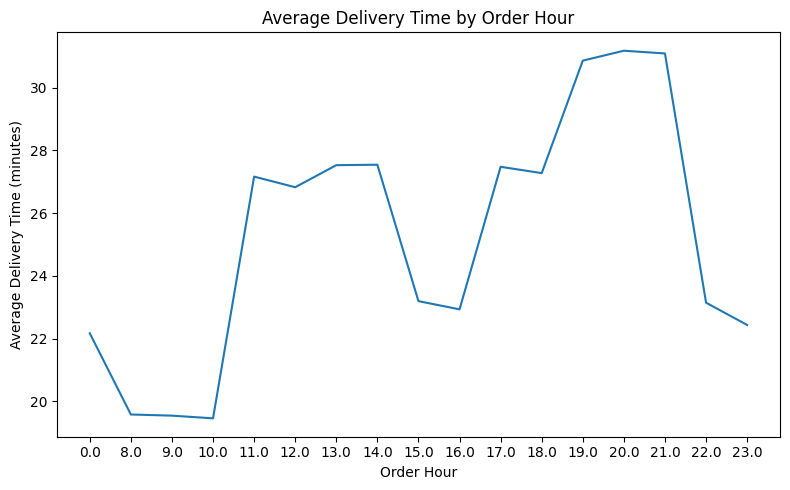

In [ ]:
hour_time = df.groupby("Order_Hour")["Time_taken (min)"].mean()

plt.figure(figsize=(8, 5))

plt.plot(hour_time.index.astype(str), hour_time.values)

plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Order Hour")

plt.xticks(hour_time.index.astype(str))

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_order_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os
os.getcwd()

'e:\\python_projects\\Food-Delivery-Analytics\\Python'

In [ ]:
os.listdir()

['food_delivery_analysis.ipynb']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/zomato_delivery_cleaned.csv")

In [ ]:
df.shape

(45584, 20)

In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


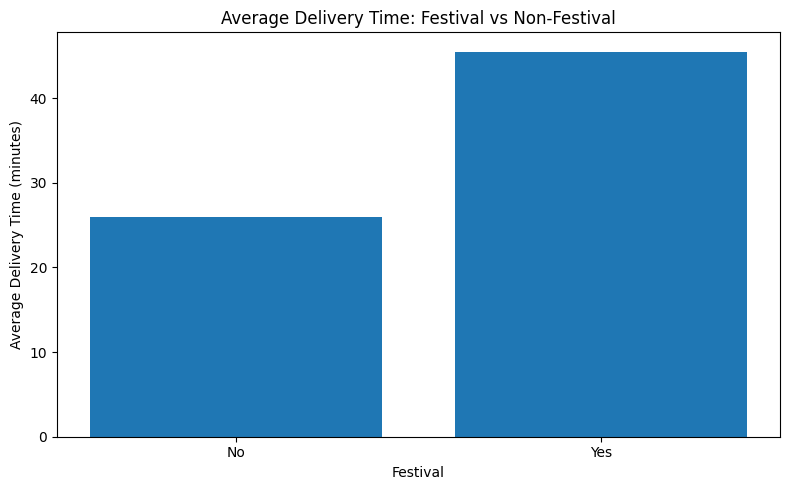

In [ ]:
festival_time = df.groupby("Festival")["Time_taken (min)"].mean()
festival_time

plt.figure(figsize=(8, 5))

plt.bar(festival_time.index, festival_time.values)

plt.xlabel("Festival")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time: Festival vs Non-Festival")

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_festival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

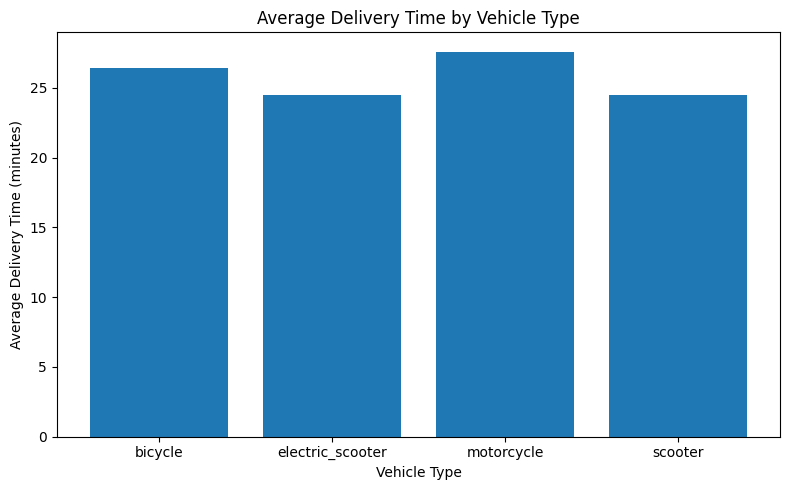

In [ ]:
vehicle_time = df.groupby("Type_of_vehicle")["Time_taken (min)"].mean()

vehicle_time

plt.figure(figsize=(8, 5))

plt.bar(vehicle_time.index, vehicle_time.values)

plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Vehicle Type")

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_vehicle.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

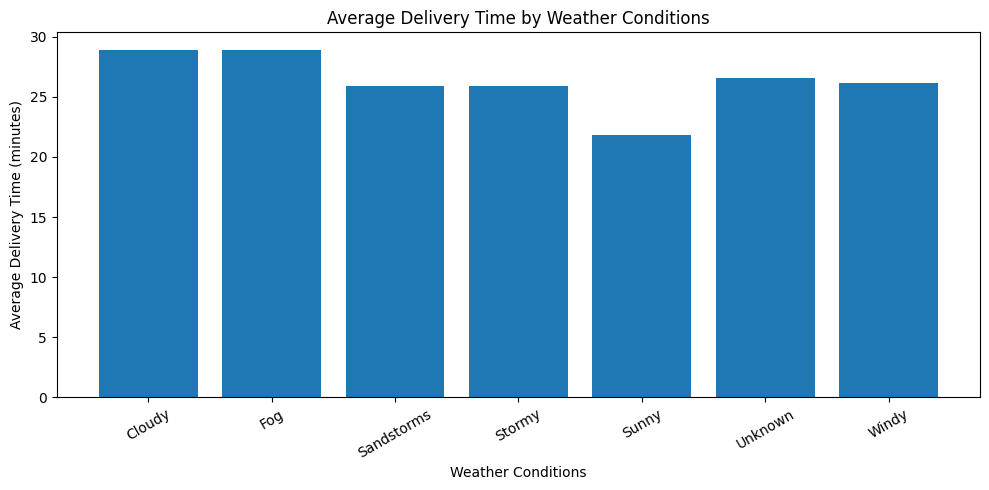

In [ ]:
weather_time = df.groupby("Weather_conditions")["Time_taken (min)"].mean()

weather_time

plt.figure(figsize=(10, 5))

plt.bar(weather_time.index, weather_time.values)

plt.xlabel("Weather Conditions")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Weather Conditions")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_weather.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

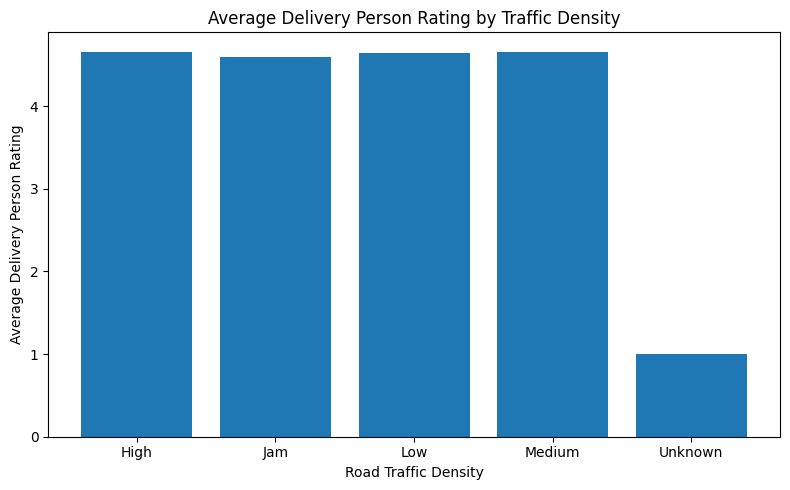

In [ ]:
rating_traffic = df.groupby("Road_traffic_density")["Delivery_person_Ratings"].mean()

rating_traffic

plt.figure(figsize=(8, 5))

plt.bar(
    rating_traffic.index.astype(str),
    rating_traffic.values
)

plt.xlabel("Road Traffic Density")
plt.ylabel("Average Delivery Person Rating")
plt.title("Average Delivery Person Rating by Traffic Density")

plt.tight_layout()

plt.savefig(
    "../Charts/average_rating_by_traffic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


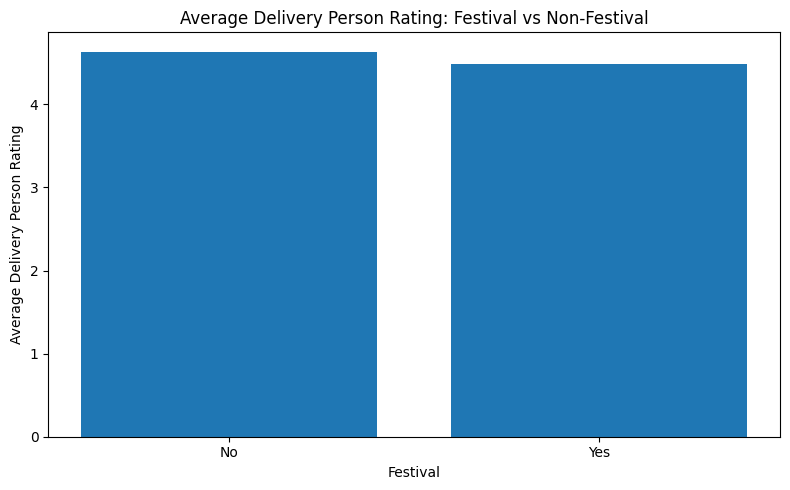

In [ ]:
rating_festival = df.groupby("Festival")["Delivery_person_Ratings"].mean()

rating_festival

plt.figure(figsize=(8, 5))

plt.bar(
    rating_festival.index.astype(str),
    rating_festival.values
)

plt.xlabel("Festival")
plt.ylabel("Average Delivery Person Rating")
plt.title("Average Delivery Person Rating: Festival vs Non-Festival")

plt.tight_layout()

plt.savefig(
    "../Charts/average_rating_by_festival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

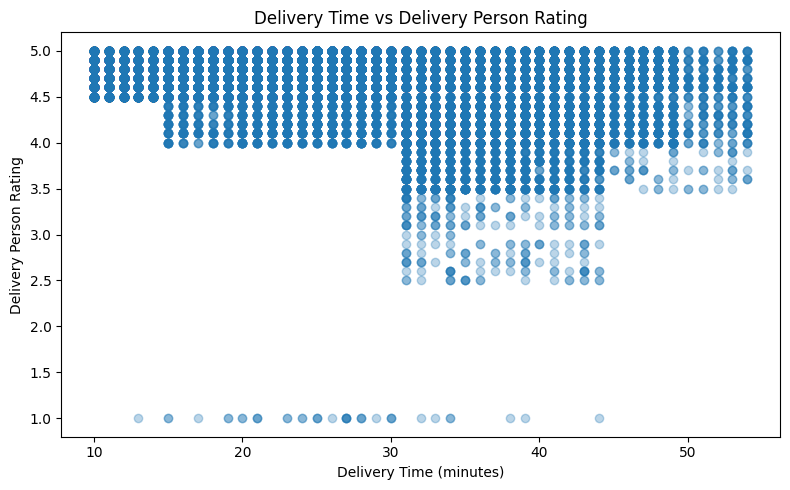

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Time_taken (min)"],
    df["Delivery_person_Ratings"],
    alpha=0.3
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Delivery Person Rating")
plt.title("Delivery Time vs Delivery Person Rating")

plt.tight_layout()

plt.savefig(
    "../Charts/delivery_time_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
df["Order_Date"].head()

0    2022-02-12
1    2022-02-13
2    2022-03-04
3    2022-02-13
4    2022-02-14
Name: Order_Date, dtype: str

In [ ]:
df.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weather_conditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken (min)',
 'Order_Hour']

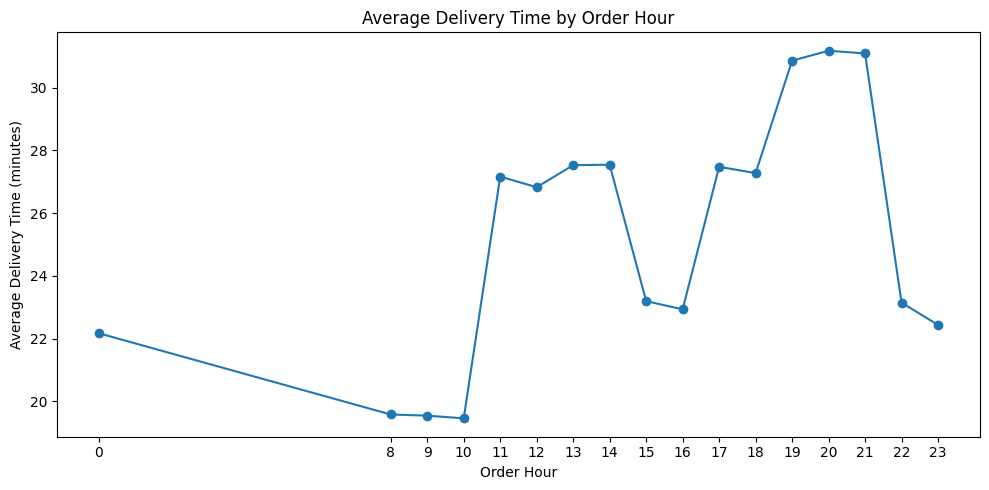

In [ ]:
hourly_delivery_time = (
    df.groupby("Order_Hour")["Time_taken (min)"]
    .mean()
    .sort_index()
)

hourly_delivery_time.index = hourly_delivery_time.index.astype(int)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_delivery_time.index,
    hourly_delivery_time.values,
    marker="o"
)

plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Order Hour")

plt.xticks(hourly_delivery_time.index)

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_order_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

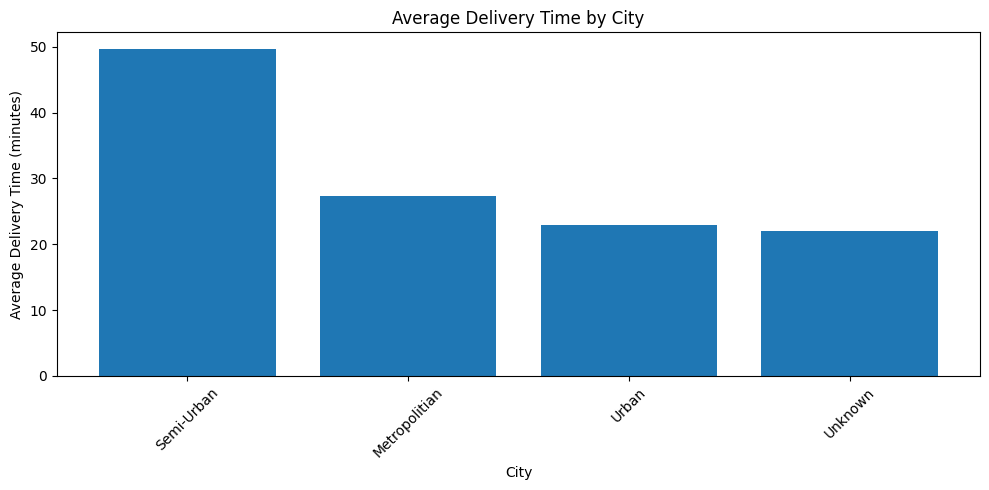

In [ ]:
city_delivery_time = (
    df.groupby("City")["Time_taken (min)"]
    .mean()
    .sort_values(ascending=False)
)

city_delivery_time

plt.figure(figsize=(10, 5))

plt.bar(
    city_delivery_time.index,
    city_delivery_time.values
)

plt.xlabel("City")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by City")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Charts/average_delivery_time_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

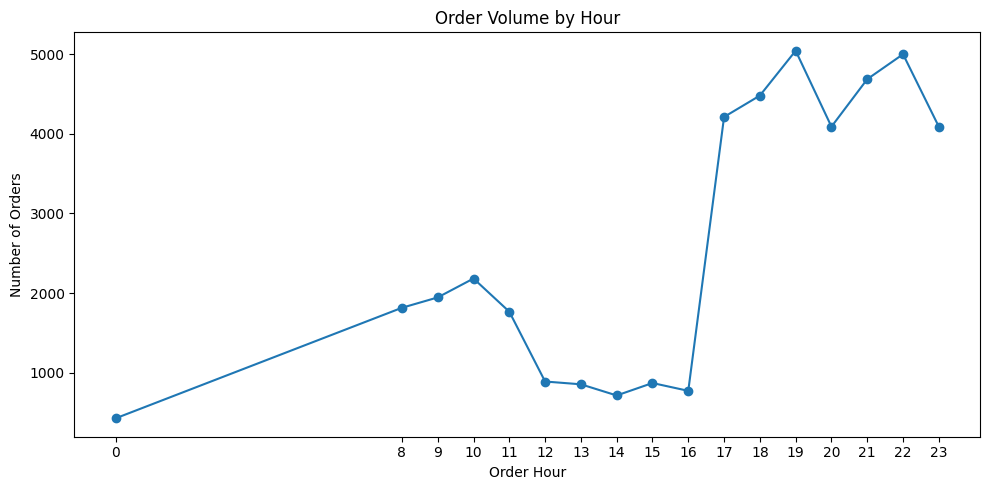

In [ ]:
orders_by_hour = df["Order_Hour"].value_counts().sort_index()

orders_by_hour.index = orders_by_hour.index.astype(int)

orders_by_hour

plt.figure(figsize=(10, 5))

plt.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    marker="o"
)

plt.xlabel("Order Hour")
plt.ylabel("Number of Orders")
plt.title("Order Volume by Hour")

plt.xticks(orders_by_hour.index)

plt.tight_layout()

plt.savefig(
    "../Charts/order_volume_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

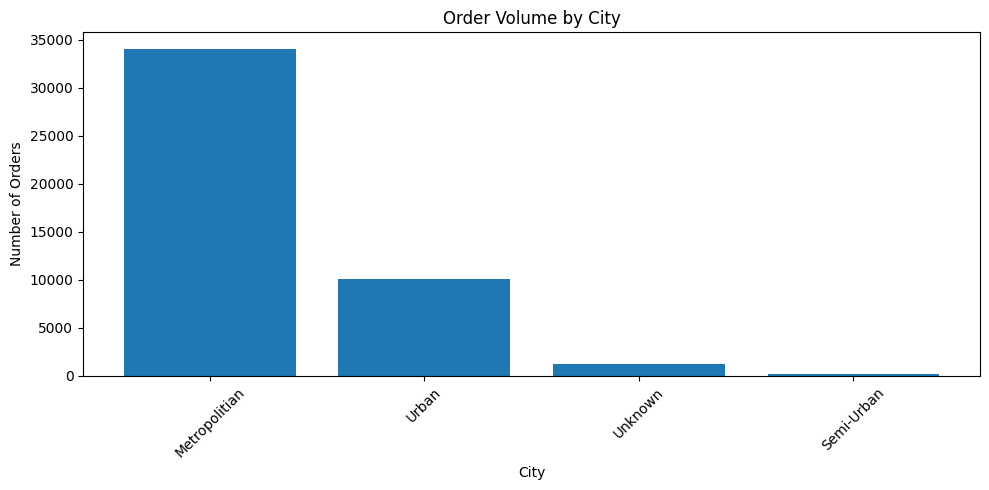

In [ ]:
orders_by_city = df["City"].value_counts()

orders_by_city
plt.figure(figsize=(10, 5))

plt.bar(
    orders_by_city.index,
    orders_by_city.values
)

plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.title("Order Volume by City")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Charts/order_volume_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

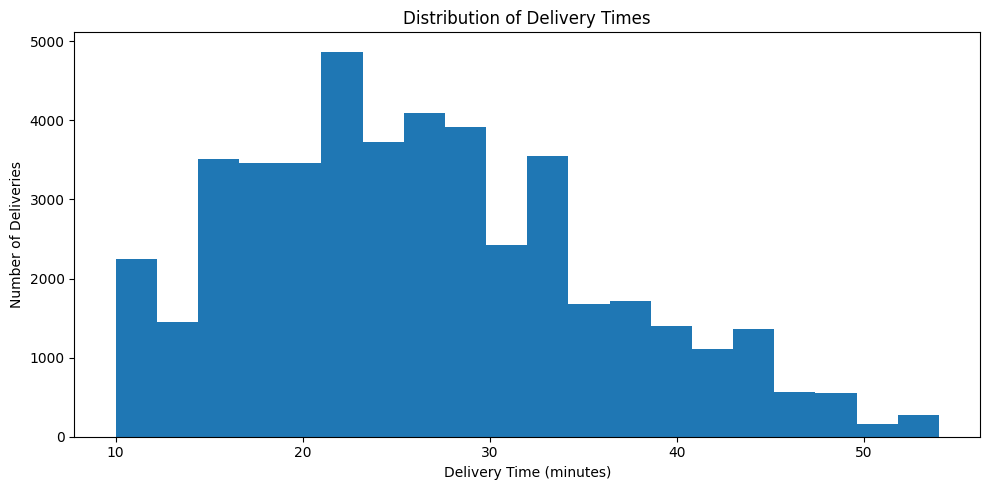

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Time_taken (min)"].dropna(),
    bins=20
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Delivery Times")

plt.tight_layout()

plt.savefig(
    "../Charts/delivery_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

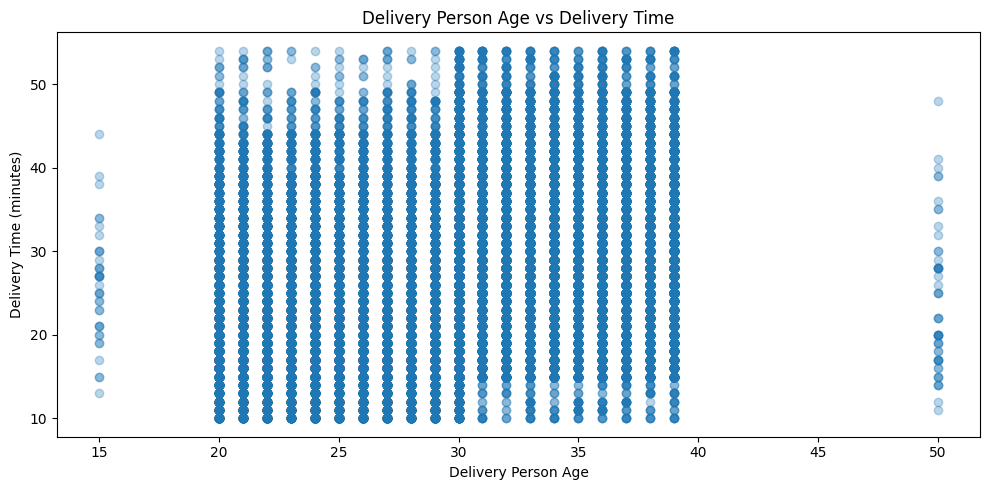

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["Delivery_person_Age"],
    df["Time_taken (min)"],
    alpha=0.3
)

plt.xlabel("Delivery Person Age")
plt.ylabel("Delivery Time (minutes)")
plt.title("Delivery Person Age vs Delivery Time")

plt.tight_layout()

plt.savefig(
    "../Charts/delivery_person_age_vs_delivery_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.Collecting seaborn
                                              0.0/294.9 kB ? eta -:--:--
     ------------------------------------   286.7/294.9 kB 8.9 MB/s eta 0:00:01
     ------------------------------------   286.7/294.9 kB 8.9 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 2.3 MB/s eta 0:00:00




[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


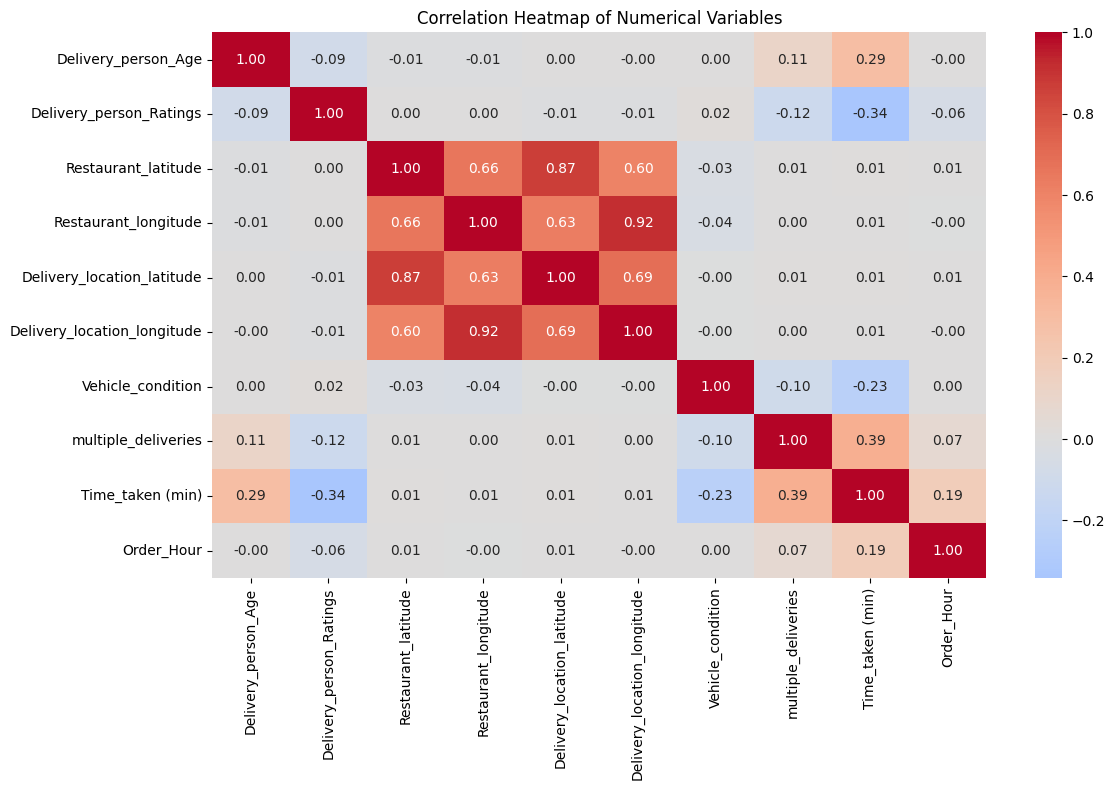

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()

plt.savefig(
    "../Charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
restaurant_locations = (
    df.groupby(["Restaurant_latitude", "Restaurant_longitude"])
    .size()
    .reset_index(name="order_count")
)

restaurant_locations.head()

,Restaurant_latitude,Restaurant_longitude,order_count
0,-30.905562,-75.832841,1
1,-30.902872,75.826808,2
2,-30.899584,75.809346,3
3,-30.895817,75.813112,3
4,-30.893384,-75.821202,1


In [ ]:
top_restaurants = (
    restaurant_locations
    .sort_values("order_count", ascending=False)
    .head(10)
)

top_restaurants

,Restaurant_latitude,Restaurant_longitude,order_count
315,0.000000,0.000000,3640
653,26.911378,75.789034,182
658,26.914142,75.805704,180
648,26.902908,75.792934,176
646,26.892312,75.806896,176
649,26.902940,75.793007,176
644,26.888420,75.800689,174
656,26.913726,75.752820,173
651,26.905287,75.794592,173
655,26.913483,75.803139,172


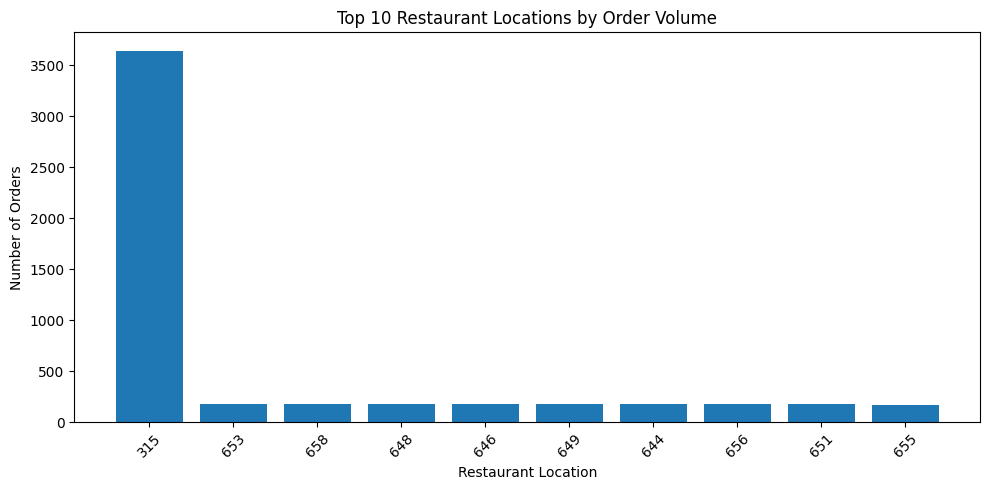

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_restaurants.index.astype(str),
    top_restaurants["order_count"]
)

plt.xlabel("Restaurant Location")
plt.ylabel("Number of Orders")
plt.title("Top 10 Restaurant Locations by Order Volume")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Charts/top_10_restaurant_locations_by_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insights

## 1. Multiple Deliveries Increase Delivery Time

Multiple deliveries show a positive relationship with delivery time. The correlation between `multiple_deliveries` and `Time_taken (min)` is approximately **0.39**.

This indicates that deliveries involving multiple orders tend to take longer.

## 2. Longer Delivery Times Are Associated with Lower Ratings

There is a negative correlation of approximately **-0.34** between `Time_taken (min)` and `Delivery_person_Ratings`.

This suggests that longer delivery times tend to be associated with lower ratings.

## 3. Evening Hours Have Higher Delivery Times

The hourly analysis shows that average delivery time increases during the evening, with the highest values occurring around **19:00–21:00**.

This indicates that evening periods may require additional delivery capacity.

## 4. Traffic Conditions Affect Delivery Performance

Average delivery time varies across different road traffic conditions.

This highlights traffic as an important factor affecting delivery performance.

## 5. Delivery Performance Varies by City

The analysis shows differences in average delivery time between cities.

Cities with higher average delivery times may require further investigation.

## 6. Weather and Festival Conditions Can Influence Delivery Time

Delivery times vary across different weather and festival conditions.

These factors should be considered when planning delivery resources.

# Conclusion

This analysis explored food delivery operations to understand the factors that influence delivery performance and customer satisfaction.

The analysis found that multiple deliveries, traffic conditions, weather, festival conditions, vehicle type, time of day, and city are associated with differences in delivery time.

The analysis also showed a negative relationship between delivery time and delivery-person ratings, suggesting that reducing delivery delays can help improve service quality.

The findings can help a food delivery platform improve delivery planning, allocate resources during peak periods, optimize multiple deliveries, and identify cities or conditions where operational improvements are needed.

Overall, the analysis demonstrates how data can be used to understand delivery performance and support data-driven operational decisions.

In [2]:
df = pd.read_csv("../Data/zomato_delivery_cleaned.csv")

In [3]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [4]:
import sqlite3 
import pandas as pd
conn = sqlite3.connect("../SQL/zomato_delivery_cleaned.db")
df.to_sql("deliveries", conn, if_exists="replace", index = False)
print("Database Created Successfully")



Database Created Successfully


In [5]:
result = pd.read_sql_query(
    "SELECT COUNT(*) AS total_orders FROM deliveries",
    conn
)

result

,total_orders
0,45584


In [6]:
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,deliveries


In [7]:
import os

print(os.path.abspath("../SQL/zomato_delivery_cleaned.db"))

e:\python_projects\Food-Delivery-Analytics\SQL\zomato_delivery_cleaned.db


In [8]:
import sqlite3

conn = sqlite3.connect("../Data/zomato_delivery_cleaned.db")

print(conn)

In [9]:
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

cursor.fetchall()

[]

In [10]:
import os

os.listdir("../Data")

['Zomato Dataset.csv',
 'zomato_delivery_cleaned.csv',
 'zomato_delivery_cleaned.db']

In [4]:
import pandas as pd

df = pd.read_csv("../Data/zomato_delivery_cleaned.csv")

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [6]:
print(df.columns)

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='str')
